In [63]:
import os
import pandas as pd
import numpy as np
import time
from collections import Counter, defaultdict
import matplotlib.pyplot as plt

from datasets import load_dataset
import tiktoken
from openai import OpenAI

In [64]:
df_rag = load_dataset("neural-bridge/rag-hallucination-dataset-1000")
df1 = df_rag['train'].to_pandas()
df2 = df_rag['test'].to_pandas()
df_rag = pd.concat([df1, df2], axis=0)
df_rag.head(2)

,context,question,answer
0,The Lothian Cycle Campaign\nA new underpass of...,What is the proposed design of the underpass a...,This question cannot be answered.
1,Courage under fire. Farah Naqvi writes.india U...,What was John F Kennedy's stance on the first ...,This question cannot be answered.


In [65]:
def count_tokens(text):
    encoding = tiktoken.get_encoding("cl100k_base")
    tokens = encoding.encode(text)
    return len(tokens)

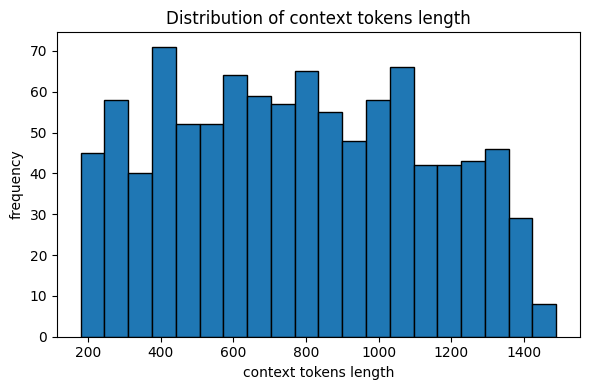

In [66]:
df_rag['token'] = df_rag['context'].apply(count_tokens)
plt.figure(figsize=(6,4))
_ = plt.hist(df_rag['token'], bins=20, ec='black')
plt.xlabel('context tokens length')
plt.ylabel('frequency')
plt.title('Distribution of context tokens length')
plt.tight_layout()

In [67]:
df_rag = pd.read_csv("hallucination_50.csv")
print(len(df_rag))
df_rag.head(2)

50


,context,question,answer
0,Project Description\nBRIGHTDELIGHT – Checkmate...,Who is the lead vocalist for BrightDelight?,This question cannot be answered using the con...
1,Port Harcourt – The Rivers police command on W...,What is the maximum penalty for the offence un...,This question cannot be answered using the con...


In [68]:
indx = 5
print("Context: \n")
print(df_rag["context"].iloc[indx])

print("\nQuestion: \n")
print(df_rag["question"].iloc[indx])

print("\nAnswer: \n")
print(df_rag["answer"].iloc[indx])

Context: 

.
Tags: smart meters
July 10, 2011 at 8:22 pm |
Ralph, thanks for writing about this. My husband is very concerned about the possibly health hazard posed by smart meter (we have resisted having cell phones thus far). Would be very interested in followup info on your experimental solution.
July 11, 2011 at 4:05 am |
Hi neighbor. We have had a sign on our for a few months not to “upgrade” it to smart meter and the old one remains — for now. We are also on the delay list. One thing I don;t understand is out here in the boonies where there is no cell reception, where do they transmit to, satellite? How can that be? I guess they have the juice to do what they want.
Chuck
July 17, 2011 at 6:26 am |
SmartCage@ for Smart Meters… go to smartcage.com (available)… Ralph, I want to go into business with you on this. 🙂
–Allan
July 31, 2011 at 9:38 pm |
I used to work in a Rudolf Steiner school in Bærum, Norway, where cell phones were to be switched off at any time, not for any educationa

In [69]:
llm_models=[
    "openai/gpt-4.1",
    "anthropic/claude-sonnet-4",
    "google/gemini-2.5-flash",  #"google/gemini-2.5-pro",
    "x-ai/grok-3",
    "deepseek/deepseek-chat-v3-0324",
    "meta-llama/llama-4-maverick",
]

In [70]:
# llm_models=[
#     "google/gemma-3n-e2b-it:free",
#     "mistralai/mistral-small-3.2-24b-instruct:free"
# ]

In [71]:
def create_prompt(context, question):
    return f"""
    You are a highly factual assistant. 
    You must only answer using the information found *explicitly* in the provided context.
    If the context does **not contain** a direct and complete answer, 
    you must respond **only and exactly** with:
    "This question cannot be answered using the context provided."
    Do **not** summarize, rephrase, assume, infer, or speculate beyond the given context.
    
    Context: {context}
    
    Question: {question}
    
    Answer:
    """


In [72]:
client = OpenAI(
    api_key=os.getenv("OPENROUTER_API_KEY"),
    base_url=os.getenv("OPENROUTER_BASE_URL")
)

In [73]:
num_repeats = 5
n = 10 # number of examples per run

all_response_dict = defaultdict(lambda: defaultdict(list))  
all_incorrect_responses = defaultdict(list)  
all_processing_times = defaultdict(list)  

for run in range(num_repeats):
    print(f"Run {run + 1}/{num_repeats}")
    start = run * n
    end = start + n
    batch_df = df_rag.iloc[start:end]

    for model_name in llm_models:
        print(f"  Testing model: {model_name}")
        
        correct = 0
        start_time = time.time()
        
        for i, example in batch_df.iterrows():
            context = example['context']
            question = example['question']
            full_prompt = create_prompt(context, question)
            
            response = client.chat.completions.create(
                model=model_name,
                max_completion_tokens=100,
                messages=[
                    {"role": "user", "content": full_prompt}
                ]
            )
            
            result = response.choices[0].message.content.strip()

            if "this question cannot be answered using the context provided" in result.lower():
                correct += 1

            all_response_dict[question][model_name].append(result)

        elapsed_time = time.time() - start_time
        
        incorrect = n - correct
        all_incorrect_responses[model_name].append(incorrect)
        all_processing_times[model_name].append(elapsed_time)

Run 1/5
  Testing model: openai/gpt-4.1
  Testing model: anthropic/claude-sonnet-4
  Testing model: google/gemini-2.5-flash
  Testing model: x-ai/grok-3
  Testing model: deepseek/deepseek-chat-v3-0324
  Testing model: meta-llama/llama-4-maverick
Run 2/5
  Testing model: openai/gpt-4.1
  Testing model: anthropic/claude-sonnet-4
  Testing model: google/gemini-2.5-flash
  Testing model: x-ai/grok-3
  Testing model: deepseek/deepseek-chat-v3-0324
  Testing model: meta-llama/llama-4-maverick
Run 3/5
  Testing model: openai/gpt-4.1
  Testing model: anthropic/claude-sonnet-4
  Testing model: google/gemini-2.5-flash
  Testing model: x-ai/grok-3
  Testing model: deepseek/deepseek-chat-v3-0324
  Testing model: meta-llama/llama-4-maverick
Run 4/5
  Testing model: openai/gpt-4.1
  Testing model: anthropic/claude-sonnet-4
  Testing model: google/gemini-2.5-flash
  Testing model: x-ai/grok-3
  Testing model: deepseek/deepseek-chat-v3-0324
  Testing model: meta-llama/llama-4-maverick
Run 5/5
  Testin

In [74]:
df_responses = pd.DataFrame.from_dict(all_response_dict, orient='index')
df_responses.reset_index(inplace=True)
df_responses.rename(columns={"index": "Question"}, inplace=True)
df_responses.to_csv("llm_responses.csv", index=False)
df_responses.head(10)

,Question,openai/gpt-4.1,anthropic/claude-sonnet-4,google/gemini-2.5-flash,x-ai/grok-3,deepseek/deepseek-chat-v3-0324,meta-llama/llama-4-maverick
0,Who is the lead vocalist for BrightDelight?,[This question cannot be answered using the co...,[This question cannot be answered using the co...,[This question cannot be answered using the co...,[This question cannot be answered using the co...,[This question cannot be answered using the co...,[This question cannot be answered using the co...
1,What is the maximum penalty for the offence un...,[This question cannot be answered using the co...,[This question cannot be answered using the co...,[This question cannot be answered using the co...,[This question cannot be answered using the co...,[This question cannot be answered using the co...,[This question cannot be answered using the co...
2,What are the operating hours of the Extra Spac...,[This question cannot be answered using the co...,[This question cannot be answered using the co...,[This question cannot be answered using the co...,[This question cannot be answered using the co...,[This question cannot be answered using the co...,[This question cannot be answered using the co...
3,Who is the founder of The Estée Edit brand?,[This question cannot be answered using the co...,[This question cannot be answered using the co...,[This question cannot be answered using the co...,[This question cannot be answered using the co...,[This question cannot be answered using the co...,[This question cannot be answered using the co...
4,What is the exact date of the installation of ...,[This question cannot be answered using the co...,[This question cannot be answered using the co...,[This question cannot be answered using the co...,[This question cannot be answered using the co...,[This question cannot be answered using the co...,[This question cannot be answered using the co...
5,What is the health hazard posed by smart meters?,[This question cannot be answered using the co...,[This question cannot be answered using the co...,[This question cannot be answered using the co...,[This question cannot be answered using the co...,[The context does not contain a direct and com...,[This question cannot be answered using the co...
6,Who is the creator of the Gundam series?,[This question cannot be answered using the co...,[This question cannot be answered using the co...,[This question cannot be answered using the co...,[This question cannot be answered using the co...,[This question cannot be answered using the co...,[This question cannot be answered using the co...
7,What is the exact date for the first full day ...,[This question cannot be answered using the co...,[This question cannot be answered using the co...,[This question cannot be answered using the co...,[This question cannot be answered using the co...,[This question cannot be answered using the co...,[This question cannot be answered using the co...
8,Who designed the interior of The Milk Factory?,[This question cannot be answered using the co...,[This question cannot be answered using the co...,[This question cannot be answered using the co...,[This question cannot be answered using the co...,[This question cannot be answered using the co...,[This question cannot be answered using the co...
9,What is the name of the Pontiac man who was sp...,[This question cannot be answered using the co...,[This question cannot be answered using the co...,[This question cannot be answered using the co...,[This question cannot be answered using the co...,[This question cannot be answered using the co...,[This question cannot be answered using the co...


In [90]:
summary_data = []
for model_name, run_scores in all_incorrect_responses.items():
    mean_val = 100*np.mean(run_scores)/n
    std_val = 100*np.std(run_scores, ddof=1)/n  # sample std deviation
    row = [model_name] + run_scores + [round(mean_val, 2), round(std_val, 2)]
    summary_data.append(row)

df_summary = pd.DataFrame(
    summary_data,
    columns=["Model", "Run1", "Run2", "Run3", "Run4", "Run5", "hallucination_rate", "hallucination_rate_std"]
)

df_summary.to_csv("hallucination_stats.csv", index=False)
df_summary.head(10)


,Model,Run1,Run2,Run3,Run4,Run5,hallucination_rate,hallucination_rate_std
0,openai/gpt-4.1,0,0,0,0,0,0.0,0.00
1,anthropic/claude-sonnet-4,0,0,0,0,0,0.0,0.00
2,google/gemini-2.5-flash,0,0,0,0,0,0.0,0.00
3,x-ai/grok-3,0,0,0,0,1,2.0,4.47
4,deepseek/deepseek-chat-v3-0324,0,0,0,0,1,2.0,4.47
5,meta-llama/llama-4-maverick,0,0,0,0,0,0.0,0.00


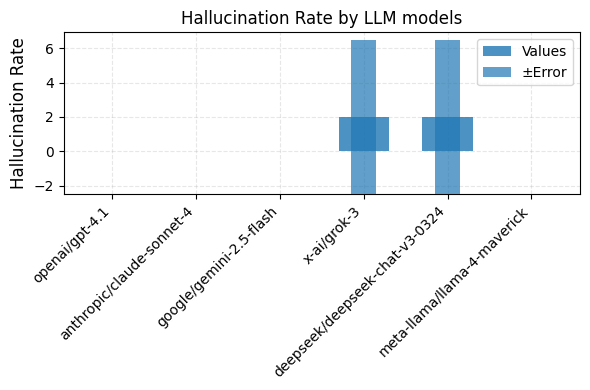

In [91]:
categories = df_summary['Model']
values = df_summary['hallucination_rate']
errors = df_summary['hallucination_rate_std']

fig, ax = plt.subplots(figsize=(6, 4))
bar_width = 0.6
error_bar_width = 0.3  
x_pos = np.arange(len(categories))
main_bars = ax.bar(x_pos, values, bar_width, alpha=0.8, label='Values', zorder=2, color='tab:blue')
upper_error_bars = ax.bar(x_pos, errors, error_bar_width, bottom=values,
                          alpha=0.7, label='±Error', zorder=3, color='tab:blue')
lower_error_bars = ax.bar(x_pos, errors, error_bar_width, bottom=np.array(values) - np.array(errors),
                          alpha=0.7, zorder=3, color='tab:blue')

ax.set_ylabel('Hallucination Rate', fontsize=12)
ax.set_title('Hallucination Rate by LLM models', fontsize=12)
ax.set_xticks(x_pos)
ax.set_xticklabels(categories)
ax.grid(True, alpha=0.3, linestyle='--', zorder=1)
ax.legend()

plt.xticks(rotation=45,ha='right')
plt.tight_layout()
plt.savefig('hallucination_rate.png', dpi=600)

In [92]:
summary_data = []
for model_name, run_scores in all_processing_times.items():
    mean_val = np.mean(run_scores)/n
    std_val = np.std(run_scores, ddof=1)/n
    row = [model_name] + run_scores + [round(mean_val, 2), round(std_val, 2)]
    summary_data.append(row)

df_summary = pd.DataFrame(
    summary_data,
    columns=["Model", "Run1", "Run2", "Run3", "Run4", "Run5", "Mean", "Std"]
)

df_summary.to_csv("response_times.csv", index=False)
df_summary.head(10)


,Model,Run1,Run2,Run3,Run4,Run5,Mean,Std
0,openai/gpt-4.1,9.885434,10.995116,8.683037,9.079164,9.238039,0.96,0.09
1,anthropic/claude-sonnet-4,34.493728,23.470383,23.430160,25.661949,19.681836,2.53,0.55
2,google/gemini-2.5-flash,11.736154,8.919635,10.851306,8.326609,7.902154,0.95,0.17
3,x-ai/grok-3,9.034616,10.426215,10.167408,9.050494,9.944967,0.97,0.06
4,deepseek/deepseek-chat-v3-0324,17.127470,30.046001,16.706985,15.865617,17.903484,1.95,0.59
5,meta-llama/llama-4-maverick,9.269413,7.961251,7.972842,10.748008,10.183388,0.92,0.13


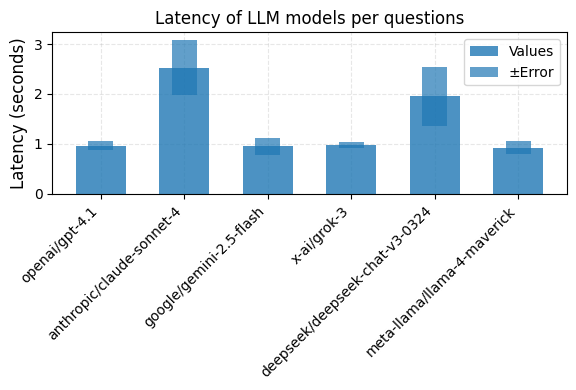

In [93]:
categories = df_summary['Model']
values = df_summary['Mean']
errors = df_summary['Std']

fig, ax = plt.subplots(figsize=(6, 4))
bar_width = 0.6
error_bar_width = 0.3  
x_pos = np.arange(len(categories))
main_bars = ax.bar(x_pos, values, bar_width, alpha=0.8, label='Values', zorder=2, color='tab:blue')
upper_error_bars = ax.bar(x_pos, errors, error_bar_width, bottom=values,
                          alpha=0.7, label='±Error', zorder=3, color='tab:blue')
lower_error_bars = ax.bar(x_pos, errors, error_bar_width, bottom=np.array(values) - np.array(errors),
                          alpha=0.7, zorder=3, color='tab:blue')
ax.set_ylabel('Latency (seconds)', fontsize=12)
ax.set_title('Latency of LLM models per questions', fontsize=12)
ax.set_xticks(x_pos)
ax.set_xticklabels(categories)
ax.grid(True, alpha=0.3, linestyle='--', zorder=1)
ax.legend()
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('latency.png', dpi=600)

In [79]:
exit("stop here.....")

In [106]:
df_or = pd.read_csv("~/Downloads/openrouter_activity_2025-07-12.csv")
print(len(df_or))
df_or.head()

671


,generation_id,created_at,cost_total,cost_web_search,cost_cache,cost_file_processing,tokens_prompt,tokens_completion,tokens_reasoning,model_permaslug,provider_name,variant,cancelled,streamed,finish_reason_raw,finish_reason_normalized,generation_time_ms,time_to_first_token_ms,app_name,api_key_name
0,gen-1752278157-1eCujo5FRE86DCHmo4Uk,2025-07-11 23:55:56.332,0.000337,NaN,NaN,NaN,999,15,0,google/gemini-2.5-flash,Google,standard,False,True,STOP,stop,589,532,NaN,hallucination
1,gen-1752278155-kLvqosMlyCOvi0B8wEYn,2025-07-11 23:55:54.536,0.000438,NaN,NaN,NaN,1179,34,0,google/gemini-2.5-flash,Google,standard,False,True,STOP,stop,680,509,NaN,hallucination
2,gen-1752277833-NTeZGLOJU0iyCdjOsf3J,2025-07-11 23:50:32.213,0.000511,NaN,NaN,NaN,1179,63,0,google/gemini-2.5-flash,Google,standard,False,True,STOP,stop,1894,1532,NaN,hallucination
3,gen-1752277719-EPEt0POvYw7LEQm3Abge,2025-07-11 23:48:38.245,0.000174,NaN,NaN,NaN,1121,10,0,openai/gpt-4o-mini,OpenAI,standard,False,True,stop,stop,59,590,NaN,hallucination
4,gen-1752276997-AFHcLKwjk3ScSCop8PYp,2025-07-11 23:36:35.977,0.000174,NaN,NaN,NaN,1121,10,0,openai/gpt-4o-mini,OpenAI,standard,False,True,stop,stop,102,582,NaN,hallucination


In [111]:
df_or_avg = df_or.groupby('model_permaslug')[['cost_total', 'generation_time_ms', 'time_to_first_token_ms']].mean().reset_index()


In [112]:
models_permaslug = ['openai/gpt-4.1-2025-04-14',
          'anthropic/claude-3-7-sonnet-20250219',
          'google/gemini-2.5-flash',
          'x-ai/grok-3',
          'deepseek/deepseek-chat-v3-0324',
          'meta-llama/llama-4-maverick-17b-128e-instruct',
          ]

In [113]:
df_or_avg = df_or_avg[df_or_avg['model_permaslug'].isin(models_permaslug)]
df_or_avg.head(10)

,model_permaslug,cost_total,generation_time_ms,time_to_first_token_ms
0,anthropic/claude-3-7-sonnet-20250219,0.000537,324.000000,981.000000
2,deepseek/deepseek-chat-v3-0324,0.000370,1188.382716,1072.395062
3,google/gemini-2.5-flash,0.000430,2163.750000,1961.000000
6,meta-llama/llama-4-maverick-17b-128e-instruct,0.000186,181.604938,615.234568
8,openai/gpt-4.1-2025-04-14,0.002003,273.250000,858.826087
11,x-ai/grok-3,0.002911,715.419753,1081.740741


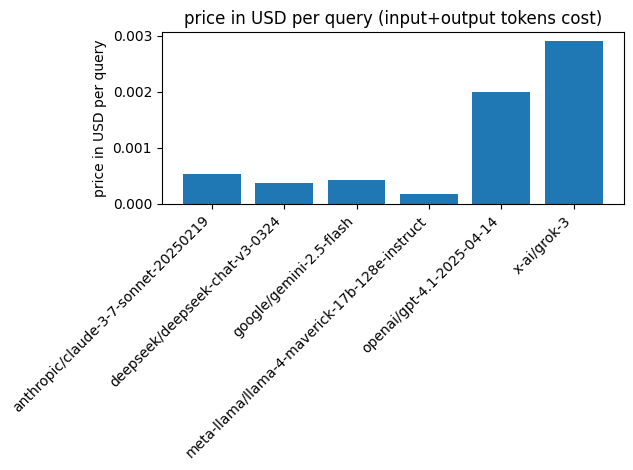

In [122]:
plt.bar(df_or_avg['model_permaslug'], df_or_avg['cost_total'])
plt.xticks(rotation=45, ha='right')
plt.ylabel("price in USD per query")
plt.title("price in USD per query (input+output tokens cost)")
plt.tight_layout()

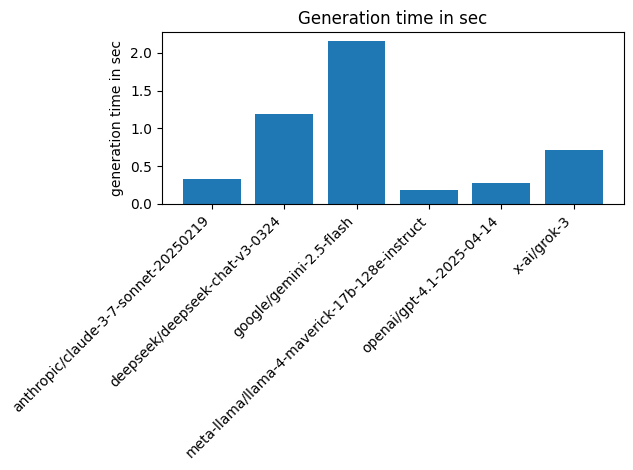

In [126]:
plt.bar(df_or_avg['model_permaslug'], df_or_avg['generation_time_ms']/1000)
plt.xticks(rotation=45, ha='right')
plt.ylabel("generation time in sec")
plt.title("Generation time in sec")
plt.tight_layout()

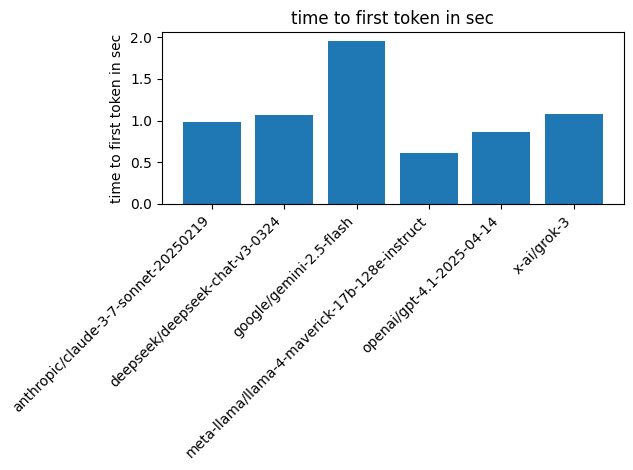

In [127]:
plt.bar(df_or_avg['model_permaslug'], df_or_avg['time_to_first_token_ms']/1000)
plt.xticks(rotation=45, ha='right')
plt.ylabel("time to first token in sec")
plt.title("time to first token in sec")
plt.tight_layout()